In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Define the file path and file names
data_path = '/content/'
filenames = [
    'actual_sequences.parquet',
    'invalid_sequence_score.parquet',
    'package_data.parquet',
    'route_data.parquet',
    'travel_times.parquet'
]

# Create a dictionary to store DataFrames
dataframes = {}

# Load each file into a pandas DataFrame and store it in the dictionary
for filename in filenames:
    file_path = data_path + filename
    df_name = filename.split('.')[0]  # Use file name (without extension) as the key
    if filename.endswith('.parquet'):
        dataframes[df_name] = pd.read_parquet(file_path)
    elif filename.endswith('.csv'):
        dataframes[df_name] = pd.read_csv(file_path)
    else:
        print(f"Unsupported file format for {filename}")

# Display the names and the first few rows of each DataFrame
for df_name, df in dataframes.items():
    print(f"{df_name}:")
    print(df, "\n")

actual_sequences:
                                             RouteID StopID  Rank
0       RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77     VE     0
1       RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77     TG     1
2       RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77     GP     2
3       RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77     HT     3
4       RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77     AG     4
...                                              ...    ...   ...
904522  RouteID_fffd257c-3041-4736-be7a-5efea8af1173     WT   169
904523  RouteID_fffd257c-3041-4736-be7a-5efea8af1173     XJ   170
904524  RouteID_fffd257c-3041-4736-be7a-5efea8af1173     NX   171
904525  RouteID_fffd257c-3041-4736-be7a-5efea8af1173     JN   172
904526  RouteID_fffd257c-3041-4736-be7a-5efea8af1173     DE   173

[904527 rows x 3 columns] 

invalid_sequence_score:
                                           RouteID     Score
0     RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77  0.631275
1     RouteID_0

# Adding Features to the dataset
Dask was used to run parallel processing on the CPU so that the feature adding doesnt take 15 hours, and instead 30ish seconds.

In [ ]:
import pandas as pd
import numpy as np
from dask import dataframe as dd

def create_route_features(actual_sequences, invalid_sequence_score, package_data, route_data, travel_times):
    # Convert dataframes to Dask dataframes for parallel processing
    d_actual_sequences = dd.from_pandas(actual_sequences, npartitions=10)
    d_invalid_sequence_score = dd.from_pandas(invalid_sequence_score, npartitions=10)
    d_package_data = dd.from_pandas(package_data, npartitions=10)
    d_route_data = dd.from_pandas(route_data, npartitions=10)
    d_travel_times = dd.from_pandas(travel_times, npartitions=10)

    # Precompute route-level features
    route_features = route_data[['RouteID', 'StationCode', 'TruckCapacity', 'DepartureTimeUTC']].drop_duplicates()
    route_features['DepartureHour'] = pd.to_datetime(route_features['DepartureTimeUTC']).dt.hour

    # Add basic route information and invalid sequence score
    route_features = route_features.merge(invalid_sequence_score, on='RouteID', how='left', suffixes=('', '_invalid'))
    route_features['InvalidSequenceScore'] = route_features['Score'].fillna(0)

    # Add total stops and package-related features
    stop_counts = d_actual_sequences.groupby('RouteID').size().compute()
    package_counts = d_package_data.groupby('RouteID').size().compute()
    unique_stops_with_packages = d_package_data.groupby('RouteID')['StopID'].nunique().compute()

    # Aggregate service time statistics
    planned_service_times = d_package_data.groupby('RouteID')['Planned_Service_Time_Seconds'].agg(
        total_service_time='sum', avg_service_time='mean').compute()

    # Merge computed package-related features into route_features
    route_features = (
        route_features
        .merge(stop_counts.rename('TotalStops'), on='RouteID', how='left')
        .merge(package_counts.rename('TotalPackages'), on='RouteID', how='left')
        .merge(unique_stops_with_packages.rename('UniqueStopsWithPackages'), on='RouteID', how='left')
        .merge(planned_service_times, on='RouteID', how='left')
    )

    # Calculate average packages per stop
    route_features['AvgPackagesPerStop'] = route_features['TotalPackages'] / route_features['UniqueStopsWithPackages']
    route_features['AvgServiceTimePerStop'] = route_features['avg_service_time']

    # Calculate package volume by first ensuring the volume column is computed
    d_package_data['volume'] = d_package_data['Depth_cm'] * d_package_data['Height_cm'] * d_package_data['Width_cm']

    # Compute average and total package volume per RouteID
    avg_package_volume = d_package_data.groupby('RouteID')['volume'].mean().compute()
    total_package_volume = d_package_data.groupby('RouteID')['volume'].sum().compute()

    # Merge the computed values into route_features DataFrame
    route_features['AvgPackageVolume'] = route_features['RouteID'].map(avg_package_volume)
    route_features['TotalPackageVolume'] = route_features['RouteID'].map(total_package_volume)

    # Calculate volume utilization
    route_features['VolumeUtilization'] = route_features['TotalPackageVolume'] / route_features['TruckCapacity']


    # Time window percentage
    time_window_packages = d_package_data[~d_package_data['Start_Time_UTC'].isna()]
    time_window_percentage = (
        time_window_packages.groupby('RouteID').size() / d_package_data.groupby('RouteID').size()
    ).fillna(0)

    # Convert to pandas Series and then to a dictionary
    time_window_percentage_dict = time_window_percentage.compute().to_dict()

    # Now map the dictionary to 'RouteID'
    route_features['PercentageTimeWindowPackages'] = route_features['RouteID'].map(time_window_percentage_dict)


    # Travel time features
    travel_time_stats = d_travel_times.groupby('RouteID')['TravelTime'].agg(['mean', 'sum']).compute()
    travel_time_stats.columns = ['avg_travel_time', 'total_travel_time']
    route_features = route_features.merge(travel_time_stats, on='RouteID', how='left')

    # Average time per stop (service + travel time)
    route_features['AvgTotalTimePerStop'] = (
        (route_features['total_travel_time'] + route_features['total_service_time']) / route_features['TotalStops']
    )

    # Geographic area calculations
    geo_stats = route_data.groupby('RouteID').agg({'Latitude': ['max', 'min'], 'Longitude': ['max', 'min']})
    geo_stats.columns = ['Lat_Max', 'Lat_Min', 'Lon_Max', 'Lon_Min']
    geo_stats['LatitudeSpread'] = geo_stats['Lat_Max'] - geo_stats['Lat_Min']
    geo_stats['LongitudeSpread'] = geo_stats['Lon_Max'] - geo_stats['Lon_Min']
    geo_stats['GeographicArea'] = geo_stats['LatitudeSpread'] * geo_stats['LongitudeSpread']

    route_features = route_features.merge(geo_stats[['LatitudeSpread', 'LongitudeSpread', 'GeographicArea']],
                                          on='RouteID', how='left')

    return route_features

In [ ]:
actual_sequences, invalid_sequence_score, package_data, route_data, travel_times = dataframes['actual_sequences'].copy(), dataframes['invalid_sequence_score'].copy(), dataframes['package_data'].copy(), dataframes['route_data'].copy(), dataframes['travel_times'].copy()
features_df = create_route_features(actual_sequences, invalid_sequence_score,
                                    package_data, route_data, travel_times)

route_scores = route_data[['RouteID', 'RouteScore']].drop_duplicates()

score_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
route_scores['RouteScore_Numeric'] = route_scores['RouteScore'].map(score_mapping)

data = features_df.merge(route_scores, on='RouteID')

In [ ]:
data

,RouteID,StationCode,TruckCapacity,DepartureTimeUTC,DepartureHour,Score,InvalidSequenceScore,TotalStops,TotalPackages,UniqueStopsWithPackages,...,VolumeUtilization,PercentageTimeWindowPackages,avg_travel_time,total_travel_time,AvgTotalTimePerStop,LatitudeSpread,LongitudeSpread,GeographicArea,RouteScore,RouteScore_Numeric
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,16:02:10,16,0.631275,0.631275,119,276,118,...,0.915265,0.199275,234.724815,3323938.1,28041.000000,0.094882,0.150200,0.014251,High,2
1,RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,DSE4,4247527.0,15:44:41,15,0.447396,0.447396,106,199,105,...,0.498257,0.085427,250.400169,2813496.3,26718.114151,0.264314,0.063131,0.016686,High,2
2,RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,DSE5,4247527.0,15:32:04,15,0.585464,0.585464,128,212,127,...,0.576562,0.117925,336.257318,5509239.9,43188.992188,0.206095,0.299541,0.061734,High,2
3,RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,DLA9,3313071.0,15:09:38,15,0.696672,0.696672,142,241,141,...,0.663581,0.087137,300.221752,6053671.4,42740.476761,0.144189,0.222372,0.032064,High,2
4,RouteID_0021a2aa-780f-460d-b09a-f301709e2523,DLA7,3313071.0,14:23:26,14,1.246236,1.246236,155,219,154,...,0.723480,0.004566,425.770027,10229124.9,66089.384516,0.125796,0.145253,0.018272,High,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,RouteID_ffd16e94-e3db-435f-a128-1ddcb2a34e54,DAU1,4247527.0,13:47:59,13,0.962153,0.962153,83,159,82,...,0.470312,0.276730,294.636159,2029748.5,24670.038554,0.174466,0.049132,0.008572,Medium,1
6108,RouteID_ffe98097-93df-44b0-9c45-4fedbafae3f3,DCH4,3313071.0,14:07:25,14,0.929612,0.929612,149,206,148,...,0.758565,0.043689,614.151223,13634771.3,91602.729530,0.108940,0.305957,0.033331,Medium,1
6109,RouteID_ffebb6fc-ce81-46db-b2a1-2750c0333185,DCH3,3313071.0,14:10:26,14,0.986821,0.986821,190,269,189,...,0.700707,0.070632,380.863277,13749164.3,72444.015263,0.066716,0.281026,0.018749,High,2
6110,RouteID_fff2548c-1069-4340-8e50-08420efe435d,DLA8,4247527.0,15:13:39,15,0.441373,0.441373,75,206,74,...,0.601295,0.126214,278.709796,1567742.6,21124.180000,0.151968,0.048590,0.007384,High,2


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, classification_report
import warnings
warnings.filterwarnings('ignore')

# Stops into columns
Instead of having the stops be sequenced in actual sequences, i gave them their own column and started at rank 1 instead of 0 for each route. This helps the random forest learn which stop order is best (i think).

In [ ]:
actual_sequences, invalid_sequence_score, package_data, route_data, travel_times = dataframes['actual_sequences'].copy(), dataframes['invalid_sequence_score'].copy(), dataframes['package_data'].copy(), dataframes['route_data'].copy(), dataframes['travel_times'].copy()

actual_sequences['Rank_Adjusted'] = actual_sequences['Rank'] + 1

# Create the pivot table
stop_rank_matrix = actual_sequences.pivot(
    index='RouteID',
    columns='StopID',
    values='Rank_Adjusted'
).fillna(0)  # Stops not visited get 0

# Rename columns to indicate  stop ranks
stop_rank_matrix.columns = [f'Stop_{col}_Rank' for col in stop_rank_matrix.columns]

print("Shape of stop rank matrix:", stop_rank_matrix.shape)
print("\nFirst few rows and columns:")
print(stop_rank_matrix.iloc[:5, :5])

Shape of stop rank matrix: (6112, 675)

First few rows and columns:
                                              Stop_AA_Rank  Stop_AB_Rank  \
RouteID                                                                    
RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77           0.0           0.0   
RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59           0.0           0.0   
RouteID_001948e9-4675-486d-9ec5-912fd8e0770f          59.0           0.0   
RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f           0.0         123.0   
RouteID_0021a2aa-780f-460d-b09a-f301709e2523          44.0          55.0   

                                              Stop_AC_Rank  Stop_AD_Rank  \
RouteID                                                                    
RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77           0.0         106.0   
RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59          37.0           0.0   
RouteID_001948e9-4675-486d-9ec5-912fd8e0770f           0.0          95.0   
RouteID_001b4ee3-c4

In [ ]:
stop_rank_matrix

,Stop_AA_Rank,Stop_AB_Rank,Stop_AC_Rank,Stop_AD_Rank,Stop_AE_Rank,Stop_AF_Rank,Stop_AG_Rank,Stop_AH_Rank,Stop_AI_Rank,Stop_AJ_Rank,...,Stop_ZP_Rank,Stop_ZQ_Rank,Stop_ZR_Rank,Stop_ZS_Rank,Stop_ZT_Rank,Stop_ZU_Rank,Stop_ZV_Rank,Stop_ZW_Rank,Stop_ZX_Rank,Stop_ZY_Rank
RouteID,,,,,,,,,,,,,,,,,,,,,
RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,0.0,0.0,0.0,106.0,0.0,48.0,5.0,0.0,0.0,0.0,...,101.0,0.0,0.0,0.0,0.0,63.0,0.0,0.0,0.0,0.0
RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,0.0,0.0,37.0,0.0,29.0,0.0,105.0,0.0,0.0,0.0,...,0.0,0.0,0.0,66.0,0.0,0.0,55.0,0.0,0.0,0.0
RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,59.0,0.0,0.0,95.0,0.0,0.0,0.0,0.0,0.0,42.0,...,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,0.0,123.0,40.0,0.0,0.0,0.0,28.0,0.0,17.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RouteID_0021a2aa-780f-460d-b09a-f301709e2523,44.0,55.0,0.0,0.0,0.0,73.0,32.0,0.0,14.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RouteID_ffd16e94-e3db-435f-a128-1ddcb2a34e54,65.0,0.0,0.0,0.0,0.0,0.0,58.0,66.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,82.0,0.0,0.0,56.0,0.0
RouteID_ffe98097-93df-44b0-9c45-4fedbafae3f3,0.0,0.0,64.0,0.0,0.0,91.0,0.0,43.0,0.0,47.0,...,0.0,0.0,134.0,144.0,93.0,0.0,0.0,0.0,138.0,0.0
RouteID_ffebb6fc-ce81-46db-b2a1-2750c0333185,103.0,0.0,0.0,0.0,159.0,126.0,0.0,0.0,0.0,111.0,...,0.0,185.0,0.0,69.0,33.0,0.0,0.0,0.0,143.0,0.0


There are many, many columns

In [ ]:
final_data = data.merge(stop_rank_matrix, on='RouteID', how='left')

print("Shape of final dataset:", final_data.shape)
print("\nColumns in final dataset:")
print(final_data.columns.tolist())

Shape of final dataset: (6112, 701)

Columns in final dataset:
['RouteID', 'StationCode', 'TruckCapacity', 'DepartureTimeUTC', 'DepartureHour', 'Score', 'InvalidSequenceScore', 'TotalStops', 'TotalPackages', 'UniqueStopsWithPackages', 'total_service_time', 'avg_service_time', 'AvgPackagesPerStop', 'AvgServiceTimePerStop', 'AvgPackageVolume', 'TotalPackageVolume', 'VolumeUtilization', 'PercentageTimeWindowPackages', 'avg_travel_time', 'total_travel_time', 'AvgTotalTimePerStop', 'LatitudeSpread', 'LongitudeSpread', 'GeographicArea', 'RouteScore', 'RouteScore_Numeric', 'Stop_AA_Rank', 'Stop_AB_Rank', 'Stop_AC_Rank', 'Stop_AD_Rank', 'Stop_AE_Rank', 'Stop_AF_Rank', 'Stop_AG_Rank', 'Stop_AH_Rank', 'Stop_AI_Rank', 'Stop_AJ_Rank', 'Stop_AK_Rank', 'Stop_AL_Rank', 'Stop_AM_Rank', 'Stop_AN_Rank', 'Stop_AO_Rank', 'Stop_AP_Rank', 'Stop_AQ_Rank', 'Stop_AR_Rank', 'Stop_AS_Rank', 'Stop_AT_Rank', 'Stop_AU_Rank', 'Stop_AV_Rank', 'Stop_AW_Rank', 'Stop_AX_Rank', 'Stop_AY_Rank', 'Stop_AZ_Rank', 'Stop_BA_Ra

In [ ]:
final_data

,RouteID,StationCode,TruckCapacity,DepartureTimeUTC,DepartureHour,Score,InvalidSequenceScore,TotalStops,TotalPackages,UniqueStopsWithPackages,...,Stop_ZP_Rank,Stop_ZQ_Rank,Stop_ZR_Rank,Stop_ZS_Rank,Stop_ZT_Rank,Stop_ZU_Rank,Stop_ZV_Rank,Stop_ZW_Rank,Stop_ZX_Rank,Stop_ZY_Rank
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,16:02:10,16,0.631275,0.631275,119,276,118,...,101.0,0.0,0.0,0.0,0.0,63.0,0.0,0.0,0.0,0.0
1,RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,DSE4,4247527.0,15:44:41,15,0.447396,0.447396,106,199,105,...,0.0,0.0,0.0,66.0,0.0,0.0,55.0,0.0,0.0,0.0
2,RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,DSE5,4247527.0,15:32:04,15,0.585464,0.585464,128,212,127,...,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,DLA9,3313071.0,15:09:38,15,0.696672,0.696672,142,241,141,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,RouteID_0021a2aa-780f-460d-b09a-f301709e2523,DLA7,3313071.0,14:23:26,14,1.246236,1.246236,155,219,154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,RouteID_ffd16e94-e3db-435f-a128-1ddcb2a34e54,DAU1,4247527.0,13:47:59,13,0.962153,0.962153,83,159,82,...,0.0,0.0,0.0,0.0,0.0,82.0,0.0,0.0,56.0,0.0
6108,RouteID_ffe98097-93df-44b0-9c45-4fedbafae3f3,DCH4,3313071.0,14:07:25,14,0.929612,0.929612,149,206,148,...,0.0,0.0,134.0,144.0,93.0,0.0,0.0,0.0,138.0,0.0
6109,RouteID_ffebb6fc-ce81-46db-b2a1-2750c0333185,DCH3,3313071.0,14:10:26,14,0.986821,0.986821,190,269,189,...,0.0,185.0,0.0,69.0,33.0,0.0,0.0,0.0,143.0,0.0
6110,RouteID_fff2548c-1069-4340-8e50-08420efe435d,DLA8,4247527.0,15:13:39,15,0.441373,0.441373,75,206,74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Prepare features and target for invalid sequence score prediction
features = final_data.drop(['RouteID', 'StationCode', 'DepartureTimeUTC',
                          'Score', 'RouteScore', 'RouteScore_Numeric',
                          'InvalidSequenceScore'], axis=1)
target_regression = final_data['InvalidSequenceScore']
target_classification = final_data['RouteScore_Numeric']

# Split the data for both models
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    features, target_regression, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    features, target_classification, test_size=0.2, random_state=42
)

In [ ]:
# Scale features for regression
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Scale features for classification
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [ ]:
# Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = rf_reg.predict(X_test_reg_scaled)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"RMSE for Invalid Sequence Score prediction: {rmse:.4f}")

# Get most important features that affected the regressions choice
feature_importance_reg = pd.DataFrame({
    'feature': features.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features for Invalid Sequence Score prediction:")
print(feature_importance_reg.head(10))

RMSE for Invalid Sequence Score prediction: 0.0969

Top 10 Important Features for Invalid Sequence Score prediction:
                         feature  importance
15           AvgTotalTimePerStop    0.249598
18                GeographicArea    0.235406
14             total_travel_time    0.182008
16                LatitudeSpread    0.110083
17               LongitudeSpread    0.067177
13               avg_travel_time    0.017366
1                  DepartureHour    0.004376
7             AvgPackagesPerStop    0.004076
11             VolumeUtilization    0.002799
12  PercentageTimeWindowPackages    0.002722


In [ ]:
rf_reg.score(X_test_reg_scaled, y_test_reg)

0.8625956566640407

Pretty good R^2 score for test values

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

model = xgb.XGBClassifier(n_estimators=100, random_state=42)

param_grid_ = {
   "n_estimators" : [10, 20, 50],
    "learning_rate" : [0.01, 0.05, 0.1],
    'max_depth': [1, 5, 7, 10]
}
grid_search = GridSearchCV(estimator=model, param_grid = param_grid_)

grid_search.fit(X_train_clf_scaled, y_train_clf, eval_set=[(X_test_clf_scaled, y_test_clf)], verbose=False)

best_model = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_ * 100:.2f}%')

y_pred = best_model.predict(X_test_clf_scaled)
prob = best_model.predict_proba(X_test_clf_scaled)
acc = accuracy_score(y_test_clf, y_pred)
print(f'Test Accuracy: {acc * 100:.2f}%')

print(classification_report(y_pred, y_test_clf))

Best parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 20}
Best score: 63.35%
Test Accuracy: 63.94%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.84      0.62      0.71       882
           2       0.42      0.69      0.53       341

    accuracy                           0.64      1223
   macro avg       0.42      0.44      0.41      1223
weighted avg       0.73      0.64      0.66      1223



In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

model = xgb.XGBClassifier(n_estimators=100, random_state=42)

param_grid_ = {
   "n_estimators" : [20],
    "learning_rate" : [0.1],
    'max_depth': [1]
}
grid_search = GridSearchCV(estimator=model, param_grid = param_grid_)

grid_search.fit(X_train_clf_scaled, y_train_clf, eval_set=[(X_test_clf_scaled, y_test_clf)], verbose=False)

best_model = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_ * 100:.2f}%')

y_pred = best_model.predict(X_test_clf_scaled)
prob = best_model.predict_proba(X_test_clf_scaled)
acc = accuracy_score(y_test_clf, y_pred)
print(f'Test Accuracy: {acc * 100:.2f}%')

print(classification_report(y_pred, y_test_clf))

Best parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 20}
Best score: 63.35%
Test Accuracy: 63.94%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.84      0.62      0.71       882
           2       0.42      0.69      0.53       341

    accuracy                           0.64      1223
   macro avg       0.42      0.44      0.41      1223
weighted avg       0.73      0.64      0.66      1223



In [ ]:
print(f'Best parameters for XGBoost: {grid_search.best_params_}')
print(f'Best score for XGBoost: {grid_search.best_score_ * 100:.2f}%')
print(f'Test Accuracy for XGBoost: {acc * 100:.2f}%')

print(classification_report(y_pred, y_test_clf))

Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 20}
Best score for XGBoost: 63.35%
Test Accuracy for XGBoost: 63.94%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.84      0.62      0.71       882
           2       0.42      0.69      0.53       341

    accuracy                           0.64      1223
   macro avg       0.42      0.44      0.41      1223
weighted avg       0.73      0.64      0.66      1223



In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [10, 20, 50],
    'max_depth':  [5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [1, 2, 4],

}
model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=model, param_grid=param_grid)
grid_search.fit(X_train_clf_scaled, y_train_clf)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_ * 100:.2f}%')

best_model = grid_search.best_estimator_
model.fit(X_train_clf_scaled, y_train_clf)

y_pred = model.predict(X_test_clf_scaled)

acc = accuracy_score(y_test_clf, y_pred)
print(f'Test Accuracy: {acc * 100:.2f}%')
print(classification_report(y_pred, y_test_clf))

Best parameters: {'max_depth': 20, 'max_features': None, 'max_leaf_nodes': 4, 'n_estimators': 50}
Best score: 63.14%
Test Accuracy: 58.79%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.69      0.60      0.64       751
           2       0.49      0.57      0.52       472

    accuracy                           0.59      1223
   macro avg       0.39      0.39      0.39      1223
weighted avg       0.61      0.59      0.60      1223



In [ ]:
print(f'Best parameters for Random Forest: {grid_search.best_params_}')
print(f'Best scoreRandom Forest: {grid_search.best_score_ * 100:.2f}%')

best_model = grid_search.best_estimator_
model.fit(X_train_clf_scaled, y_train_clf)

y_pred = model.predict(X_test_clf_scaled)

acc = accuracy_score(y_test_clf, y_pred)
print(f'Test Accuracy Random Forest: {acc * 100:.2f}%')
print(classification_report(y_pred, y_test_clf))

Best parameters for Random Forest: {'max_depth': 20, 'max_features': None, 'max_leaf_nodes': 4, 'n_estimators': 50}
Best scoreRandom Forest: 63.14%
Test Accuracy Random Forest: 58.14%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.69      0.60      0.64       750
           2       0.48      0.56      0.51       473

    accuracy                           0.58      1223
   macro avg       0.39      0.38      0.38      1223
weighted avg       0.61      0.58      0.59      1223



In [ ]:
# Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf = rf_clf.predict(X_test_clf_scaled)

# classification report
print("Classification Report for Route Score prediction:")
print(classification_report(y_test_clf, y_pred_clf))

feature_importance_clf = pd.DataFrame({
    'feature': features.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features for Route Score prediction:")
print(feature_importance_clf.head(10))

Classification Report for Route Score prediction:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.59      0.67      0.63       650
           2       0.55      0.49      0.52       554

    accuracy                           0.58      1223
   macro avg       0.38      0.39      0.38      1223
weighted avg       0.57      0.58      0.57      1223


Top 10 Important Features for Route Score prediction:
                         feature  importance
13               avg_travel_time    0.030015
7             AvgPackagesPerStop    0.027771
15           AvgTotalTimePerStop    0.022744
14             total_travel_time    0.021774
5             total_service_time    0.018834
6               avg_service_time    0.017050
2                     TotalStops    0.016819
12  PercentageTimeWindowPackages    0.016504
4        UniqueStopsWithPackages    0.016500
3                  TotalPackages    0.016025


In [ ]:
rf_clf.score(X_test_clf_scaled, y_test_clf)

0.5772690106295993

In [ ]:
!pip install catboost
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import catboost as cat

model = cat.CatBoostClassifier()

param_cat = {
    “depth”: [1, 3, 6, 8, 10],
    “iteration”: [10, 20, 50],
    “learning_rate”: [0.01, 0.05, 0.1],
    “l2_leaf_reg”: [1, 3, 5]
}
grid_search = GridSearchCV(estimator=model, param_grid = param_cat)

grid_search.fit(X_train_clf_scaled, y_train_clf, eval_set=[(X_test_clf_scaled, y_test_clf)], verbose=False)

best_model = grid_search.best_estimator_


print(f'Best parameters for Catboost: {grid_search.best_params_}')
print(f'Best score for Catboost: {grid_search.best_score_ * 100:.2f}%')


y_pred = best_model.predict(X_test_clf_scaled)

acc = accuracy_score(y_test_clf, y_pred)
print(f'Test Accuracy for Catboost: {acc * 100:.2f}%')

print(classification_report(y_pred, y_test_clf))


Best parameters for Catboost: {'depth': 10, 'iterations': 20, 'l2_leaf_reg': 3, 'learning_rate': 0.01}
Best score for Catboost: 62.71%
Test Accuracy for Catboost: 62.63%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.84      0.61      0.71       903
           2       0.39      0.68      0.50       320

    accuracy                           0.63      1223
   macro avg       0.41      0.43      0.40      1223
weighted avg       0.73      0.63      0.65      1223



In [ ]:

print(f'Best parameters for Catboost: {grid_search.best_params_}')
print(f'Best score for Catboost: {grid_search.best_score_ * 100:.2f}%')

Best parameters for Catboost: {'depth': 10, 'iterations': 20, 'l2_leaf_reg': 3, 'learning_rate': 0.01}
Best score for Catboost: 62.71%


In [ ]:
target_classification.value_counts()

,count
RouteScore_Numeric,
1,3292
2,2718
0,102


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


Top 10 Important Features for Route Score prediction:
                          feature  importance
7              AvgPackagesPerStop    0.418234
15            AvgTotalTimePerStop    0.350568
13                avg_travel_time    0.202858
12   PercentageTimeWindowPackages    0.028340
457                  Stop_QW_Rank    0.000000
458                  Stop_QX_Rank    0.000000
459                  Stop_QY_Rank    0.000000
460                  Stop_QZ_Rank    0.000000
461                  Stop_RA_Rank    0.000000
462                  Stop_RB_Rank    0.000000


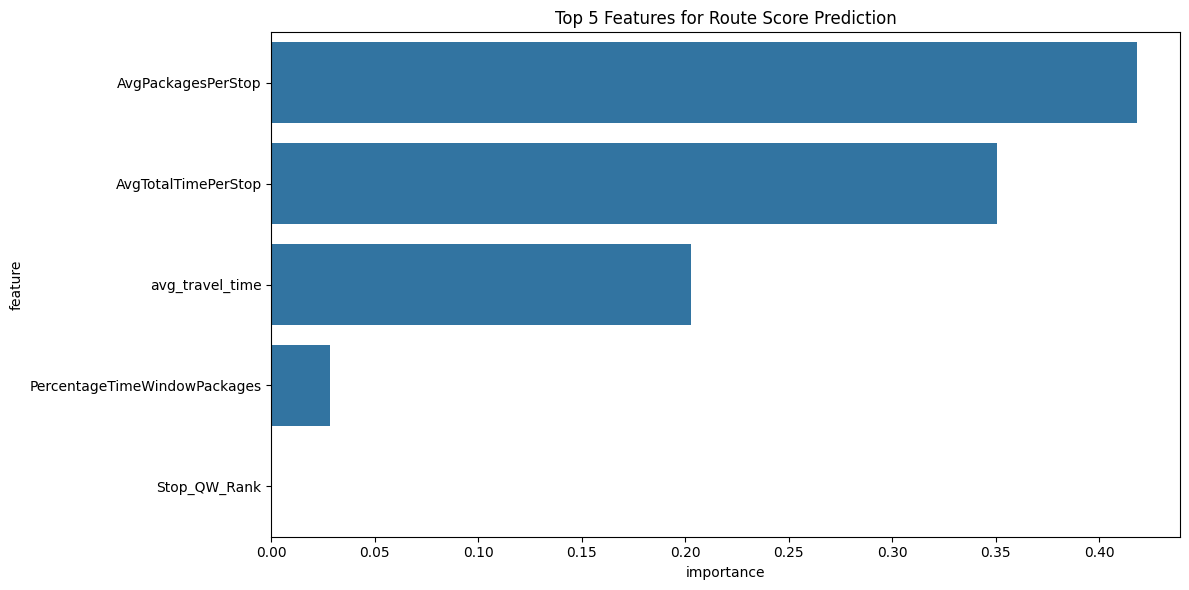

In [ ]:
# Plot feature importance for classification
feature_importance_clf = pd.DataFrame({
    'feature': features.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features for Route Score prediction:")
print(feature_importance_clf.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_clf.head(5))
plt.title('Top 5 Features for Route Score Prediction')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save models and scalers
joblib.dump(rf_reg, 'invalid_sequence_model.joblib')
joblib.dump(rf_clf, 'route_score_model.joblib')
joblib.dump(scaler_reg, 'invalid_sequence_scaler.joblib')
joblib.dump(scaler_clf, 'route_score_scaler.joblib')

['route_score_scaler.joblib']